In [ ]:
import os
import sys

import numpy as np
import pandas as pd
from collections import Counter

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../'))

from data_processing import DataProcessing

In [ ]:
load_base_data_path = DataProcessing.load_base_data_path(notebook_dir)
base_path = "classification_results/naacl_2026_submission/july_2026_results_2026-10-02"
data_path = os.path.join(load_base_data_path, base_path)
averaged_base_path = os.path.join(data_path, "averaged", "in_domain", "glodd_hristova_step0")

In [ ]:
seeds = ["seed3", "seed7", "seed33"]
models = ["spacy_small", "spacy_medium", "spacy_large"]

dist_files = {
    "All": "distribution_all.csv",
    "TOLSA-M": "distribution_tolsam.csv",
    "Non-TOLSA-M": "distribution_non_tolsam.csv"
}

In [ ]:

def load_and_average(model, dist_filename):
    """Loads a specific distribution file across all seeds and formats as Mean ± Std."""
    dfs = []
    for seed in seeds:
        path = os.path.join(data_path, seed, "in_domain", "glodd_hristova_step0", model, dist_filename)
        if os.path.exists(path):
            dfs.append(pd.read_csv(path))
            
    if not dfs:
        return None
        
    combined = pd.concat(dfs)
    
    # Calculate Mean and Std
    avg_df = combined.groupby("Category")["Count"].agg(['mean', 'std']).reset_index()
    
    # Store raw means for claim calculations later
    raw_means = avg_df.set_index("Category")['mean'].to_dict()
    
    # Format as "Mean \pm Std" for LaTeX/saving
    avg_df['Mean_Std'] = avg_df.apply(
        lambda row: f"{row['mean']:.1f} \\pm {row['std']:.1f}", axis=1
    )
    
    formatted_df = avg_df[['Category', 'Mean_Std']].rename(columns={'Mean_Std': 'Count (Mean ± Std)'})
    return formatted_df, raw_means

In [ ]:
# Process, Save, and generate LaTeX
for model in models:
    print(f"\n{'='*60}\nMODEL: {model.upper()}\n{'='*60}")
    
    # Create model specific averaged output directory
    model_out_dir = os.path.join(averaged_base_path, model)
    os.makedirs(model_out_dir, exist_ok=True)
    
    raw_averages = {}
    
    for dist_key, filename in dist_files.items():
        result = load_and_average(model, filename)
        
        if result is not None:
            formatted_df, raw_means = result
            raw_averages[dist_key] = raw_means
            
            # Save to disk
            out_csv = os.path.join(model_out_dir, f"averaged_{filename}")
            formatted_df.to_csv(out_csv, index=False)
            print(f"✓ Saved: {out_csv}")
            
            # Convert to LaTeX
            print(f"\n--- LaTeX for {dist_key.upper()} ({model}) ---")
            print(formatted_df.to_latex(index=False, escape=False, column_format='lc'))

    # ---------------------------------------------------------
    # Answering Claims A3, A4, A5, A6
    # ---------------------------------------------------------
    print(f"\n--- Claims Evidence for {model} ---")
    if "tolsam" in raw_averages and "non_tolsam" in raw_averages:
        tolsam_dict = raw_averages["tolsam"]
        nontolsam_dict = raw_averages["non_tolsam"]
        
        # Total TOLSA-M sentences
        total_tolsam = tolsam_dict.get("FLS Candidate", 0) + tolsam_dict.get("Not FLS Candidate", 0)
        
        # A3: Predictive statement without explicit predictive keyword
        tolsam_with_keyword = tolsam_dict.get("Predictive Keyword (Any POS)", 0)
        tolsam_without_keyword = total_tolsam - tolsam_with_keyword
        
        # A4: Predictive keyword without expressing a prediction
        nontolsam_with_keyword = nontolsam_dict.get("Predictive Keyword (Any POS)", 0)
        
        # A5/A6: Uncertain Terms
        tolsam_no_uncertainty = total_tolsam - tolsam_dict.get("Uncertain Term Present", 0)
        nontolsam_with_uncertainty = nontolsam_dict.get("Uncertain Term Present", 0)
        
        print(f"A3: TOLSA-M sentences WITHOUT a predictive keyword: {tolsam_without_keyword:.1f} out of {total_tolsam:.1f}")
        print(f"A4: Non-TOLSA-M sentences WITH a predictive keyword: {nontolsam_with_keyword:.1f}")
        print(f"A5: TOLSA-M sentences WITHOUT uncertain terms: {tolsam_no_uncertainty:.1f}")
        print(f"A6: Non-TOLSA-M sentences WITH uncertain terms: {nontolsam_with_uncertainty:.1f}")

In [ ]:
import os
import sys
import pandas as pd

# ============================================================
# IMPORTS / PATHS
# ============================================================

notebook_dir = os.getcwd()
sys.path.append(os.path.join(notebook_dir, "../"))

from data_processing import DataProcessing

base_data_path = DataProcessing.load_base_data_path(notebook_dir)

# Update these dates if your Glodd or CoNLL experiment folders differ.
glodd_experiment_path = os.path.join(
    base_data_path,
    "classification_results",
    "naacl_2026_submission",
    "july_2026_results_2026-10-02",
)

conll_experiment_path = os.path.join(
    base_data_path,
    "classification_results",
    "naacl_2026_submission",
    "july_2026_results_2026-10-01",
)

seeds = ["seed3", "seed7", "seed33"]

glodd_models = [
    "spacy_small",
    "spacy_medium",
    "spacy_large",
]

distribution_files = {
    "all": "distribution_all.csv",
    "tolsam": "distribution_tolsam.csv",
    "non_tolsam": "distribution_non_tolsam.csv",
}


# ============================================================
# SHARED HELPERS
# ============================================================

def format_mean_std(mean_value, std_value):
    """Format a numeric mean and standard deviation for CSV/LaTex output."""
    return f"{mean_value:.1f} $\\pm$ {std_value:.1f}"


def average_distribution_files(file_paths):
    """Average Category / Count distribution CSV files across seeds."""
    loaded_dfs = []

    for file_path in file_paths:
        if not os.path.exists(file_path):
            print(f"⚠️ Missing file: {file_path}")
            continue

        loaded_dfs.append(pd.read_csv(file_path))

    if not loaded_dfs:
        return None

    combined_df = pd.concat(
        loaded_dfs,
        ignore_index=True,
    )

    averaged_df = (
        combined_df
        .groupby("Category", sort=False)["Count"]
        .agg(["mean", "std"])
        .reset_index()
        .rename(
            columns={
                "mean": "Mean",
                "std": "Std",
            }
        )
    )

    averaged_df["Std"] = averaged_df["Std"].fillna(0.0)

    averaged_df["Count (Mean $\\pm$ Std)"] = averaged_df.apply(
        lambda row: format_mean_std(
            row["Mean"],
            row["Std"],
        ),
        axis=1,
    )

    return averaged_df


def save_distribution_outputs(
    averaged_df,
    output_dir,
    output_name,
    title,
):
    """Save raw and formatted distribution averages and print LaTex."""
    os.makedirs(output_dir, exist_ok=True)

    raw_df = averaged_df[
        ["Category", "Mean", "Std"]
    ].copy()

    formatted_df = averaged_df[
        ["Category", "Count (Mean $\\pm$ Std)"]
    ].copy()

    raw_path = os.path.join(
        output_dir,
        f"{output_name}_raw.csv",
    )

    formatted_path = os.path.join(
        output_dir,
        f"{output_name}.csv",
    )

    raw_df.to_csv(raw_path, index=False)
    formatted_df.to_csv(formatted_path, index=False)

    print(f"✓ Saved: {raw_path}")
    print(f"✓ Saved: {formatted_path}")

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    print(
        formatted_df.to_latex(
            index=False,
            escape=False,
            column_format="lc",
        )
    )


# ============================================================
# GLODD: A3 / A4
# ============================================================

def create_glodd_keyword_matrix(
    tolsam_distribution_df,
    non_tolsam_distribution_df,
):
    """
    Create the A3/A4 matrix from averaged Glodd distributions.

    A3:
        TOLSA-M sentences without a predictive keyword.

    A4:
        Non-TOLSA-M sentences with a predictive keyword.
    """
    tolsam_values = (
        tolsam_distribution_df
        .set_index("Category")
    )

    non_tolsam_values = (
        non_tolsam_distribution_df
        .set_index("Category")
    )

    total_tolsam_mean = (
        tolsam_values.loc["FLS Candidate", "Mean"]
        + tolsam_values.loc["Not FLS Candidate", "Mean"]
    )

    total_tolsam_std = (
        (
            tolsam_values.loc["FLS Candidate", "Std"] ** 2
            + tolsam_values.loc["Not FLS Candidate", "Std"] ** 2
        ) ** 0.5
    )

    total_non_tolsam_mean = (
        non_tolsam_values.loc["FLS Candidate", "Mean"]
        + non_tolsam_values.loc["Not FLS Candidate", "Mean"]
    )

    total_non_tolsam_std = (
        (
            non_tolsam_values.loc["FLS Candidate", "Std"] ** 2
            + non_tolsam_values.loc["Not FLS Candidate", "Std"] ** 2
        ) ** 0.5
    )

    tolsam_keyword_present_mean = tolsam_values.loc[
        "Predictive Keyword (Any POS)",
        "Mean",
    ]

    tolsam_keyword_present_std = tolsam_values.loc[
        "Predictive Keyword (Any POS)",
        "Std",
    ]

    non_tolsam_keyword_present_mean = non_tolsam_values.loc[
        "Predictive Keyword (Any POS)",
        "Mean",
    ]

    non_tolsam_keyword_present_std = non_tolsam_values.loc[
        "Predictive Keyword (Any POS)",
        "Std",
    ]

    tolsam_keyword_absent_mean = (
        total_tolsam_mean
        - tolsam_keyword_present_mean
    )

    tolsam_keyword_absent_std = (
        total_tolsam_std ** 2
        + tolsam_keyword_present_std ** 2
    ) ** 0.5

    non_tolsam_keyword_absent_mean = (
        total_non_tolsam_mean
        - non_tolsam_keyword_present_mean
    )

    non_tolsam_keyword_absent_std = (
        total_non_tolsam_std ** 2
        + non_tolsam_keyword_present_std ** 2
    ) ** 0.5

    matrix_df = pd.DataFrame({
        "Condition": [
            "Predictive Keyword Present",
            "Predictive Keyword Absent",
        ],
        "TOLSA-M Mean": [
            tolsam_keyword_present_mean,
            tolsam_keyword_absent_mean,
        ],
        "TOLSA-M Std": [
            tolsam_keyword_present_std,
            tolsam_keyword_absent_std,
        ],
        "Non-TOLSA-M Mean": [
            non_tolsam_keyword_present_mean,
            non_tolsam_keyword_absent_mean,
        ],
        "Non-TOLSA-M Std": [
            non_tolsam_keyword_present_std,
            non_tolsam_keyword_absent_std,
        ],
    })

    matrix_df["TOLSA-M"] = matrix_df.apply(
        lambda row: format_mean_std(
            row["TOLSA-M Mean"],
            row["TOLSA-M Std"],
        ),
        axis=1,
    )

    matrix_df["Non-TOLSA-M"] = matrix_df.apply(
        lambda row: format_mean_std(
            row["Non-TOLSA-M Mean"],
            row["Non-TOLSA-M Std"],
        ),
        axis=1,
    )

    return matrix_df


def average_glodd_results():
    """
    Average Glodd distributions separately for spaCy Small, Medium, and Large.

    Saves:
        averaged_distribution_all.csv
        averaged_distribution_tolsam.csv
        averaged_distribution_non_tolsam.csv
        glodd_predictive_keyword_matrix.csv
    """
    print("\n" + "=" * 70)
    print("AVERAGE GLODD DISTRIBUTIONS")
    print("=" * 70)

    glodd_averaged_root = os.path.join(
        glodd_experiment_path,
        "averaged",
        "in_domain",
        "glodd_hristova_step0",
    )

    for model in glodd_models:
        print("\n" + "=" * 70)
        print(f"GLODD MODEL: {model.upper()}")
        print("=" * 70)

        model_output_dir = os.path.join(
            glodd_averaged_root,
            model,
        )

        averaged_distributions = {}

        for distribution_name, filename in distribution_files.items():
            file_paths = [
                os.path.join(
                    glodd_experiment_path,
                    seed,
                    "in_domain",
                    "glodd_hristova_step0",
                    model,
                    filename,
                )
                for seed in seeds
            ]

            averaged_df = average_distribution_files(
                file_paths
            )

            if averaged_df is None:
                print(
                    f"⚠️ No Glodd files found for "
                    f"{model} / {distribution_name}"
                )
                continue

            averaged_distributions[
                distribution_name
            ] = averaged_df

            save_distribution_outputs(
                averaged_df=averaged_df,
                output_dir=model_output_dir,
                output_name=f"averaged_{filename[:-4]}",
                title=(
                    f"GLODD {model.upper()} — "
                    f"{distribution_name.upper()} DISTRIBUTION"
                ),
            )

        if (
            "tolsam" not in averaged_distributions
            or "non_tolsam" not in averaged_distributions
        ):
            continue

        keyword_matrix_df = create_glodd_keyword_matrix(
            tolsam_distribution_df=(
                averaged_distributions["tolsam"]
            ),
            non_tolsam_distribution_df=(
                averaged_distributions["non_tolsam"]
            ),
        )

        keyword_matrix_raw_df = keyword_matrix_df[
            [
                "Condition",
                "TOLSA-M Mean",
                "TOLSA-M Std",
                "Non-TOLSA-M Mean",
                "Non-TOLSA-M Std",
            ]
        ].copy()

        keyword_matrix_formatted_df = keyword_matrix_df[
            [
                "Condition",
                "TOLSA-M",
                "Non-TOLSA-M",
            ]
        ].copy()

        keyword_matrix_raw_path = os.path.join(
            model_output_dir,
            "glodd_predictive_keyword_matrix_raw.csv",
        )

        keyword_matrix_path = os.path.join(
            model_output_dir,
            "glodd_predictive_keyword_matrix.csv",
        )

        keyword_matrix_raw_df.to_csv(
            keyword_matrix_raw_path,
            index=False,
        )

        keyword_matrix_formatted_df.to_csv(
            keyword_matrix_path,
            index=False,
        )

        print(f"✓ Saved: {keyword_matrix_raw_path}")
        print(f"✓ Saved: {keyword_matrix_path}")

        print("\n" + "=" * 70)
        print(
            f"GLODD PREDICTIVE KEYWORD MATRIX "
            f"— {model.upper()}"
        )
        print("=" * 70)

        print(
            keyword_matrix_formatted_df.to_latex(
                index=False,
                escape=False,
                column_format="lcc",
            )
        )

        a3_value = keyword_matrix_df.loc[
            keyword_matrix_df["Condition"]
            == "Predictive Keyword Absent",
            "TOLSA-M Mean",
        ].iloc[0]

        a4_value = keyword_matrix_df.loc[
            keyword_matrix_df["Condition"]
            == "Predictive Keyword Present",
            "Non-TOLSA-M Mean",
        ].iloc[0]

        print(
            f"A3 — TOLSA-M without predictive keyword: "
            f"{a3_value:.1f}"
        )

        print(
            f"A4 — Non-TOLSA-M with predictive keyword: "
            f"{a4_value:.1f}"
        )




# ============================================================
# RUN BOTH
# ============================================================

# average_glodd_results()
average_conll_results()

In [3]:
base_path = (
    "classification_results/"
    "naacl_2026_submission/"
    "july_2026_results_2026-10-01"
)

conll_experiment_path = os.path.join(
    load_base_data_path,
    base_path,
)

conll_dir_name = "conll_2010_hedge_rule"

conll_output_dir = os.path.join(
    conll_experiment_path,
    "averaged",
    "in_domain",
    conll_dir_name,
)

os.makedirs(conll_output_dir, exist_ok=True)

seeds = [
    "seed3",
    "seed7",
    "seed33",
]

label_column = "Ground Truth"

distribution_files = {
    "all": "distribution_all.csv",
    "tolsam": "distribution_tolsam.csv",
    "non_tolsam": "distribution_non_tolsam.csv",
}

# CoNLL category-level binary rule flags and their matched-cue columns.
CONLL_CUE_CATEGORIES = {
    "Modal Verb": {
        "rule_column": "Rule_ModalVerb",
        "matched_column": "Matched_ModalVerb",
    },
    "Verb": {
        "rule_column": "Rule_Verb",
        "matched_column": "Matched_Verb",
    },
    "Uncertainty": {
        "rule_column": "Rule_Uncertainty",
        "matched_column": "Matched_Uncertainty",
    },
    "Generalization": {
        "rule_column": "Rule_Generalization",
        "matched_column": "Matched_Generalization",
    },
    "Qualifier": {
        "rule_column": "Rule_Qualifier",
        "matched_column": "Matched_Qualifier",
    },
    "Quantifier": {
        "rule_column": "Rule_Quantifier",
        "matched_column": "Matched_Quantifier",
    },
    "Noun": {
        "rule_column": "Rule_Noun",
        "matched_column": "Matched_Noun",
    },
    "Conjunction": {
        "rule_column": "Rule_Conjunction",
        "matched_column": "Matched_Conjunction",
    },
    "Obviousness": {
        "rule_column": "Rule_Obviousness",
        "matched_column": "Matched_Obviousness",
    },
    "Complex Phrase": {
        "rule_column": "Rule_ComplexPhrase",
        "matched_column": "Matched_ComplexPhrase",
    },
}


# ============================================================
# SHARED HELPERS
# ============================================================

def format_mean_std(mean_value, std_value):
    """Format a mean and standard deviation for LaTeX."""
    return f"{mean_value:.1f} $\\pm$ {std_value:.1f}"


def get_conll_seed_file_path(seed, filename):
    """Return one CoNLL output-file path for one seed."""
    return os.path.join(
        conll_experiment_path,
        seed,
        "in_domain",
        conll_dir_name,
        filename,
    )


def average_distribution_files(file_paths):
    """Average Category/Count distribution files across seeds."""
    loaded_dfs = []

    for file_path in file_paths:
        if not os.path.exists(file_path):
            print(f"⚠️ Missing file: {file_path}")
            continue

        loaded_dfs.append(pd.read_csv(file_path))

    if not loaded_dfs:
        return None

    combined_df = pd.concat(
        loaded_dfs,
        ignore_index=True,
    )

    averaged_df = (
        combined_df
        .groupby(
            "Category",
            sort=False,
        )["Count"]
        .agg(
            Mean="mean",
            Std="std",
        )
        .reset_index()
    )

    averaged_df["Std"] = averaged_df["Std"].fillna(0.0)

    averaged_df["Count (Mean $\\pm$ Std)"] = (
        averaged_df.apply(
            lambda row: format_mean_std(
                row["Mean"],
                row["Std"],
            ),
            axis=1,
        )
    )

    return averaged_df


def save_distribution_outputs(
    averaged_df,
    output_dir,
    output_name,
    title,
):
    """Save raw/formatted distributions and print a LaTeX table."""
    raw_df = averaged_df[
        [
            "Category",
            "Mean",
            "Std",
        ]
    ].copy()

    formatted_df = averaged_df[
        [
            "Category",
            "Count (Mean $\\pm$ Std)",
        ]
    ].copy()

    raw_path = os.path.join(
        output_dir,
        f"{output_name}_raw.csv",
    )

    formatted_path = os.path.join(
        output_dir,
        f"{output_name}.csv",
    )

    raw_df.to_csv(
        raw_path,
        index=False,
    )

    formatted_df.to_csv(
        formatted_path,
        index=False,
    )

    print(f"✓ Saved: {raw_path}")
    print(f"✓ Saved: {formatted_path}")

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    print(
        formatted_df.to_latex(
            index=False,
            escape=False,
            column_format="lc",
        )
    )


# ============================================================
# LOAD CONLL SENTENCE-LEVEL RESULTS
# ============================================================

def load_conll_sentence_level_files(
    seeds,
    label_column,
):
    """
    Load sentence_level_hedges.csv for every available seed.

    The CoNLL experiment applies rules to its full loaded dataset before
    splitting, so these files contain the rule annotations needed for
    category and cue-frequency analysis.
    """
    seed_dataframes = {}

    required_columns = [
        label_column,
        "CoNLL_Uncertain",
    ]

    required_columns.extend(
        config["rule_column"]
        for config in CONLL_CUE_CATEGORIES.values()
    )

    required_columns.extend(
        config["matched_column"]
        for config in CONLL_CUE_CATEGORIES.values()
    )

    for seed in seeds:
        file_path = get_conll_seed_file_path(
            seed,
            "sentence_level_hedges.csv",
        )

        if not os.path.exists(file_path):
            print(f"⚠️ Missing file: {file_path}")
            continue

        seed_df = pd.read_csv(file_path)

        missing_columns = [
            column
            for column in required_columns
            if column not in seed_df.columns
        ]

        if missing_columns:
            raise ValueError(
                f"Missing required columns in {file_path}: "
                f"{missing_columns}"
            )

        seed_df[label_column] = (
            pd.to_numeric(
                seed_df[label_column],
                errors="raise",
            )
            .astype(int)
        )

        seed_dataframes[seed] = seed_df

        print(
            f"✓ Loaded {seed}: "
            f"{len(seed_df)} sentence-level hedge rows"
        )

    if not seed_dataframes:
        raise FileNotFoundError(
            "No sentence_level_hedges.csv files were found."
        )

    return seed_dataframes


# ============================================================
# CATEGORY PRESENCE / ABSENCE MATRIX
# ============================================================

def create_conll_category_matrix(
    seed_dataframes,
    category_name,
    rule_column,
    label_column,
):
    """
    Average sentence counts for cue presence and absence.

    The result provides:
      - TOLSA-M sentences with and without the cue
      - non-TOLSA-M sentences with and without the cue

    For example, using Rule_ModalVerb directly supports:
      A5: TOLSA-M statements without a modal verb.
      A6: non-TOLSA-M sentences with a modal verb.
    """
    per_seed_rows = []

    for seed, df in seed_dataframes.items():
        tolsam_df = df.loc[
            df[label_column].eq(1)
        ]

        non_tolsam_df = df.loc[
            df[label_column].eq(0)
        ]

        tolsam_present = int(
            tolsam_df[rule_column].sum()
        )

        non_tolsam_present = int(
            non_tolsam_df[rule_column].sum()
        )

        per_seed_rows.extend([
            {
                "Seed": seed,
                "Condition": f"{category_name} Present",
                "TOLSA-M Count": tolsam_present,
                "Non-TOLSA-M Count": non_tolsam_present,
            },
            {
                "Seed": seed,
                "Condition": f"{category_name} Absent",
                "TOLSA-M Count": int(
                    len(tolsam_df) - tolsam_present
                ),
                "Non-TOLSA-M Count": int(
                    len(non_tolsam_df) - non_tolsam_present
                ),
            },
        ])

    per_seed_df = pd.DataFrame(per_seed_rows)

    averaged_df = (
        per_seed_df
        .groupby(
            "Condition",
            sort=False,
        )
        .agg(
            {
                "TOLSA-M Count": [
                    "mean",
                    "std",
                ],
                "Non-TOLSA-M Count": [
                    "mean",
                    "std",
                ],
            }
        )
        .reset_index()
    )

    averaged_df.columns = [
        "Condition",
        "TOLSA-M Mean",
        "TOLSA-M Std",
        "Non-TOLSA-M Mean",
        "Non-TOLSA-M Std",
    ]

    averaged_df["TOLSA-M Std"] = (
        averaged_df["TOLSA-M Std"]
        .fillna(0.0)
    )

    averaged_df["Non-TOLSA-M Std"] = (
        averaged_df["Non-TOLSA-M Std"]
        .fillna(0.0)
    )

    averaged_df["TOLSA-M"] = averaged_df.apply(
        lambda row: format_mean_std(
            row["TOLSA-M Mean"],
            row["TOLSA-M Std"],
        ),
        axis=1,
    )

    averaged_df["Non-TOLSA-M"] = averaged_df.apply(
        lambda row: format_mean_std(
            row["Non-TOLSA-M Mean"],
            row["Non-TOLSA-M Std"],
        ),
        axis=1,
    )

    return per_seed_df, averaged_df


def save_category_matrix(
    per_seed_df,
    averaged_df,
    category_slug,
    category_title,
    output_dir,
):
    """Save raw, formatted, and per-seed category presence matrices."""
    per_seed_path = os.path.join(
        output_dir,
        f"conll_{category_slug}_matrix_per_seed.csv",
    )

    raw_path = os.path.join(
        output_dir,
        f"conll_{category_slug}_matrix_raw.csv",
    )

    formatted_path = os.path.join(
        output_dir,
        f"conll_{category_slug}_matrix.csv",
    )

    formatted_df = averaged_df[
        [
            "Condition",
            "TOLSA-M",
            "Non-TOLSA-M",
        ]
    ].copy()

    raw_df = averaged_df[
        [
            "Condition",
            "TOLSA-M Mean",
            "TOLSA-M Std",
            "Non-TOLSA-M Mean",
            "Non-TOLSA-M Std",
        ]
    ].copy()

    per_seed_df.to_csv(
        per_seed_path,
        index=False,
    )

    raw_df.to_csv(
        raw_path,
        index=False,
    )

    formatted_df.to_csv(
        formatted_path,
        index=False,
    )

    print(f"✓ Saved: {per_seed_path}")
    print(f"✓ Saved: {raw_path}")
    print(f"✓ Saved: {formatted_path}")

    print("\n" + "=" * 70)
    print(f"CONLL {category_title.upper()} PRESENCE MATRIX")
    print("=" * 70)

    print(
        formatted_df.to_latex(
            index=False,
            escape=False,
            column_format="lcc",
        )
    )


# ============================================================
# MATCHED-CUE KEYWORD FREQUENCIES
# ============================================================

def extract_matched_cue_counts(
    df,
    matched_column,
):
    """
    Count matched CoNLL cue strings across sentence rows.

    A sentence can contain more than one cue, so these are cue occurrences,
    not mutually exclusive sentence counts. Empty and missing values are
    ignored.
    """
    cue_counter = Counter()

    for value in df[matched_column].dropna():
        cue_text = str(value).strip()

        if not cue_text:
            continue

        for cue in cue_text.split(";"):
            normalized_cue = cue.strip().lower()

            if normalized_cue:
                cue_counter[normalized_cue] += 1

    return cue_counter


def create_conll_cue_frequency_table(
    seed_dataframes,
    category_name,
    matched_column,
    label_column,
):
    """
    Average matched cue frequencies across seeds.

    Produces separate average counts for:
      - all rows
      - TOLSA-M rows
      - non-TOLSA-M rows
    """
    per_seed_rows = []

    for seed, df in seed_dataframes.items():
        groups = {
            "All": df,
            "TOLSA-M": df.loc[
                df[label_column].eq(1)
            ],
            "Non-TOLSA-M": df.loc[
                df[label_column].eq(0)
            ],
        }

        for group_name, group_df in groups.items():
            cue_counts = extract_matched_cue_counts(
                group_df,
                matched_column,
            )

            for cue, count in cue_counts.items():
                per_seed_rows.append({
                    "Seed": seed,
                    "Dataset Group": group_name,
                    "Cue": cue,
                    "Count": count,
                })

    if not per_seed_rows:
        return (
            pd.DataFrame(
                columns=[
                    "Seed",
                    "Dataset Group",
                    "Cue",
                    "Count",
                ]
            ),
            pd.DataFrame(
                columns=[
                    "Cue",
                    "All Mean",
                    "All Std",
                    "TOLSA-M Mean",
                    "TOLSA-M Std",
                    "Non-TOLSA-M Mean",
                    "Non-TOLSA-M Std",
                ]
            ),
        )

    per_seed_df = pd.DataFrame(per_seed_rows)

    grouped_df = (
        per_seed_df
        .groupby(
            [
                "Cue",
                "Dataset Group",
            ],
            sort=False,
        )["Count"]
        .agg(
            Mean="mean",
            Std="std",
        )
        .reset_index()
    )

    grouped_df["Std"] = grouped_df["Std"].fillna(0.0)

    all_cues = sorted(
        grouped_df["Cue"].unique()
    )

    frequency_df = pd.DataFrame({
        "Cue": all_cues,
    })

    for group_name in [
        "All",
        "TOLSA-M",
        "Non-TOLSA-M",
    ]:
        group_df = grouped_df.loc[
            grouped_df["Dataset Group"].eq(group_name),
            [
                "Cue",
                "Mean",
                "Std",
            ],
        ].rename(
            columns={
                "Mean": f"{group_name} Mean",
                "Std": f"{group_name} Std",
            }
        )

        frequency_df = frequency_df.merge(
            group_df,
            on="Cue",
            how="left",
        )

    numeric_columns = [
        column
        for column in frequency_df.columns
        if column != "Cue"
    ]

    frequency_df[numeric_columns] = (
        frequency_df[numeric_columns]
        .fillna(0.0)
    )

    for group_name in [
        "All",
        "TOLSA-M",
        "Non-TOLSA-M",
    ]:
        frequency_df[group_name] = frequency_df.apply(
            lambda row: format_mean_std(
                row[f"{group_name} Mean"],
                row[f"{group_name} Std"],
            ),
            axis=1,
        )

    frequency_df = frequency_df.sort_values(
        by="All Mean",
        ascending=False,
    ).reset_index(drop=True)

    return per_seed_df, frequency_df


def save_cue_frequency_table(
    per_seed_df,
    frequency_df,
    category_slug,
    category_title,
    output_dir,
):
    """Save detailed matched-cue frequency files and print LaTeX."""
    per_seed_path = os.path.join(
        output_dir,
        f"conll_{category_slug}_cue_frequencies_per_seed.csv",
    )

    raw_path = os.path.join(
        output_dir,
        f"conll_{category_slug}_cue_frequencies_raw.csv",
    )

    formatted_path = os.path.join(
        output_dir,
        f"conll_{category_slug}_cue_frequencies.csv",
    )

    raw_columns = [
        "Cue",
        "All Mean",
        "All Std",
        "TOLSA-M Mean",
        "TOLSA-M Std",
        "Non-TOLSA-M Mean",
        "Non-TOLSA-M Std",
    ]

    formatted_columns = [
        "Cue",
        "All",
        "TOLSA-M",
        "Non-TOLSA-M",
    ]

    per_seed_df.to_csv(
        per_seed_path,
        index=False,
    )

    if frequency_df.empty:
        empty_raw_df = pd.DataFrame(
            columns=raw_columns
        )

        empty_formatted_df = pd.DataFrame(
            columns=formatted_columns
        )

        empty_raw_df.to_csv(
            raw_path,
            index=False,
        )

        empty_formatted_df.to_csv(
            formatted_path,
            index=False,
        )

        print(
            f"⚠️ No matched cues found for "
            f"{category_title}."
        )

        print(f"✓ Saved: {per_seed_path}")
        print(f"✓ Saved: {raw_path}")
        print(f"✓ Saved: {formatted_path}")

        return

    frequency_df[raw_columns].to_csv(
        raw_path,
        index=False,
    )

    frequency_df[formatted_columns].to_csv(
        formatted_path,
        index=False,
    )

    print(f"✓ Saved: {per_seed_path}")
    print(f"✓ Saved: {raw_path}")
    print(f"✓ Saved: {formatted_path}")

    print("\n" + "=" * 70)
    print(
        f"CONLL {category_title.upper()} "
        f"CUE FREQUENCIES"
    )
    print("=" * 70)

    print(
        frequency_df[
            formatted_columns
        ].to_latex(
            index=False,
            escape=False,
            column_format="lccc",
        )
    )

# ============================================================
# CONLL DISTRIBUTION AVERAGING
# ============================================================

def average_conll_distributions():
    """Average CoNLL distribution files across the requested seeds."""
    print("\n" + "=" * 70)
    print("AVERAGE CONLL DISTRIBUTIONS")
    print("=" * 70)

    for distribution_name, filename in distribution_files.items():
        file_paths = [
            get_conll_seed_file_path(
                seed,
                filename,
            )
            for seed in seeds
        ]

        averaged_df = average_distribution_files(
            file_paths
        )

        if averaged_df is None:
            print(
                f"⚠️ No CoNLL files found for "
                f"{distribution_name}."
            )
            continue

        save_distribution_outputs(
            averaged_df=averaged_df,
            output_dir=conll_output_dir,
            output_name=f"averaged_{filename[:-4]}",
            title=(
                f"CONLL {distribution_name.upper()} "
                f"DISTRIBUTION"
            ),
        )


# ============================================================
# CONLL CUE ANALYSIS
# ============================================================

def analyze_conll_categories(
    seed_dataframes,
    label_column,
):
    """
    Create presence/absence matrices and matched-cue frequency tables
    for every CoNLL category.
    """
    print("\n" + "=" * 70)
    print("CONLL CATEGORY AND KEYWORD ANALYSIS")
    print("=" * 70)

    for category_name, config in CONLL_CUE_CATEGORIES.items():
        category_slug = (
            category_name
            .lower()
            .replace(" ", "_")
        )

        print("\n" + "-" * 70)
        print(f"CATEGORY: {category_name.upper()}")
        print("-" * 70)

        per_seed_matrix_df, averaged_matrix_df = (
            create_conll_category_matrix(
                seed_dataframes=seed_dataframes,
                category_name=category_name,
                rule_column=config["rule_column"],
                label_column=label_column,
            )
        )

        save_category_matrix(
            per_seed_df=per_seed_matrix_df,
            averaged_df=averaged_matrix_df,
            category_slug=category_slug,
            category_title=category_name,
            output_dir=conll_output_dir,
        )

        per_seed_frequency_df, cue_frequency_df = (
            create_conll_cue_frequency_table(
                seed_dataframes=seed_dataframes,
                category_name=category_name,
                matched_column=config["matched_column"],
                label_column=label_column,
            )
        )

        save_cue_frequency_table(
            per_seed_df=per_seed_frequency_df,
            frequency_df=cue_frequency_df,
            category_slug=category_slug,
            category_title=category_name,
            output_dir=conll_output_dir,
        )


# ============================================================
# A5 / A6 SUMMARY
# ============================================================

def print_a5_a6_summary(seed_dataframes, label_column):
    """Print the direct modal-verb evidence for A5 and A6."""
    _, modal_matrix_df = create_conll_category_matrix(
        seed_dataframes=seed_dataframes,
        category_name="Modal Verb",
        rule_column="Rule_ModalVerb",
        label_column=label_column,
    )

    a5_row = modal_matrix_df.loc[
        modal_matrix_df["Condition"].eq(
            "Modal Verb Absent"
        )
    ].iloc[0]

    a6_row = modal_matrix_df.loc[
        modal_matrix_df["Condition"].eq(
            "Modal Verb Present"
        )
    ].iloc[0]

    print("\n" + "=" * 70)
    print("A5 / A6 SUMMARY")
    print("=" * 70)

    print(
        "A5 — Average TOLSA-M sentences without a modal verb: "
        f"{a5_row['TOLSA-M Mean']:.1f} "
        f"± {a5_row['TOLSA-M Std']:.1f}"
    )

    print(
        "A6 — Average non-TOLSA-M sentences with a modal verb: "
        f"{a6_row['Non-TOLSA-M Mean']:.1f} "
        f"± {a6_row['Non-TOLSA-M Std']:.1f}"
    )


# ============================================================
# RUN CONLL ANALYSIS
# ============================================================

average_conll_distributions()

conll_seed_dataframes = load_conll_sentence_level_files(
    seeds=seeds,
    label_column=label_column,
)

analyze_conll_categories(
    seed_dataframes=conll_seed_dataframes,
    label_column=label_column,
)

print_a5_a6_summary(
    seed_dataframes=conll_seed_dataframes,
    label_column=label_column,
)

print("\n" + "=" * 70)
print("CONLL ANALYSIS COMPLETE")
print("=" * 70)
print(f"✓ Outputs saved under: {conll_output_dir}")

NameError: name 'os' is not defined

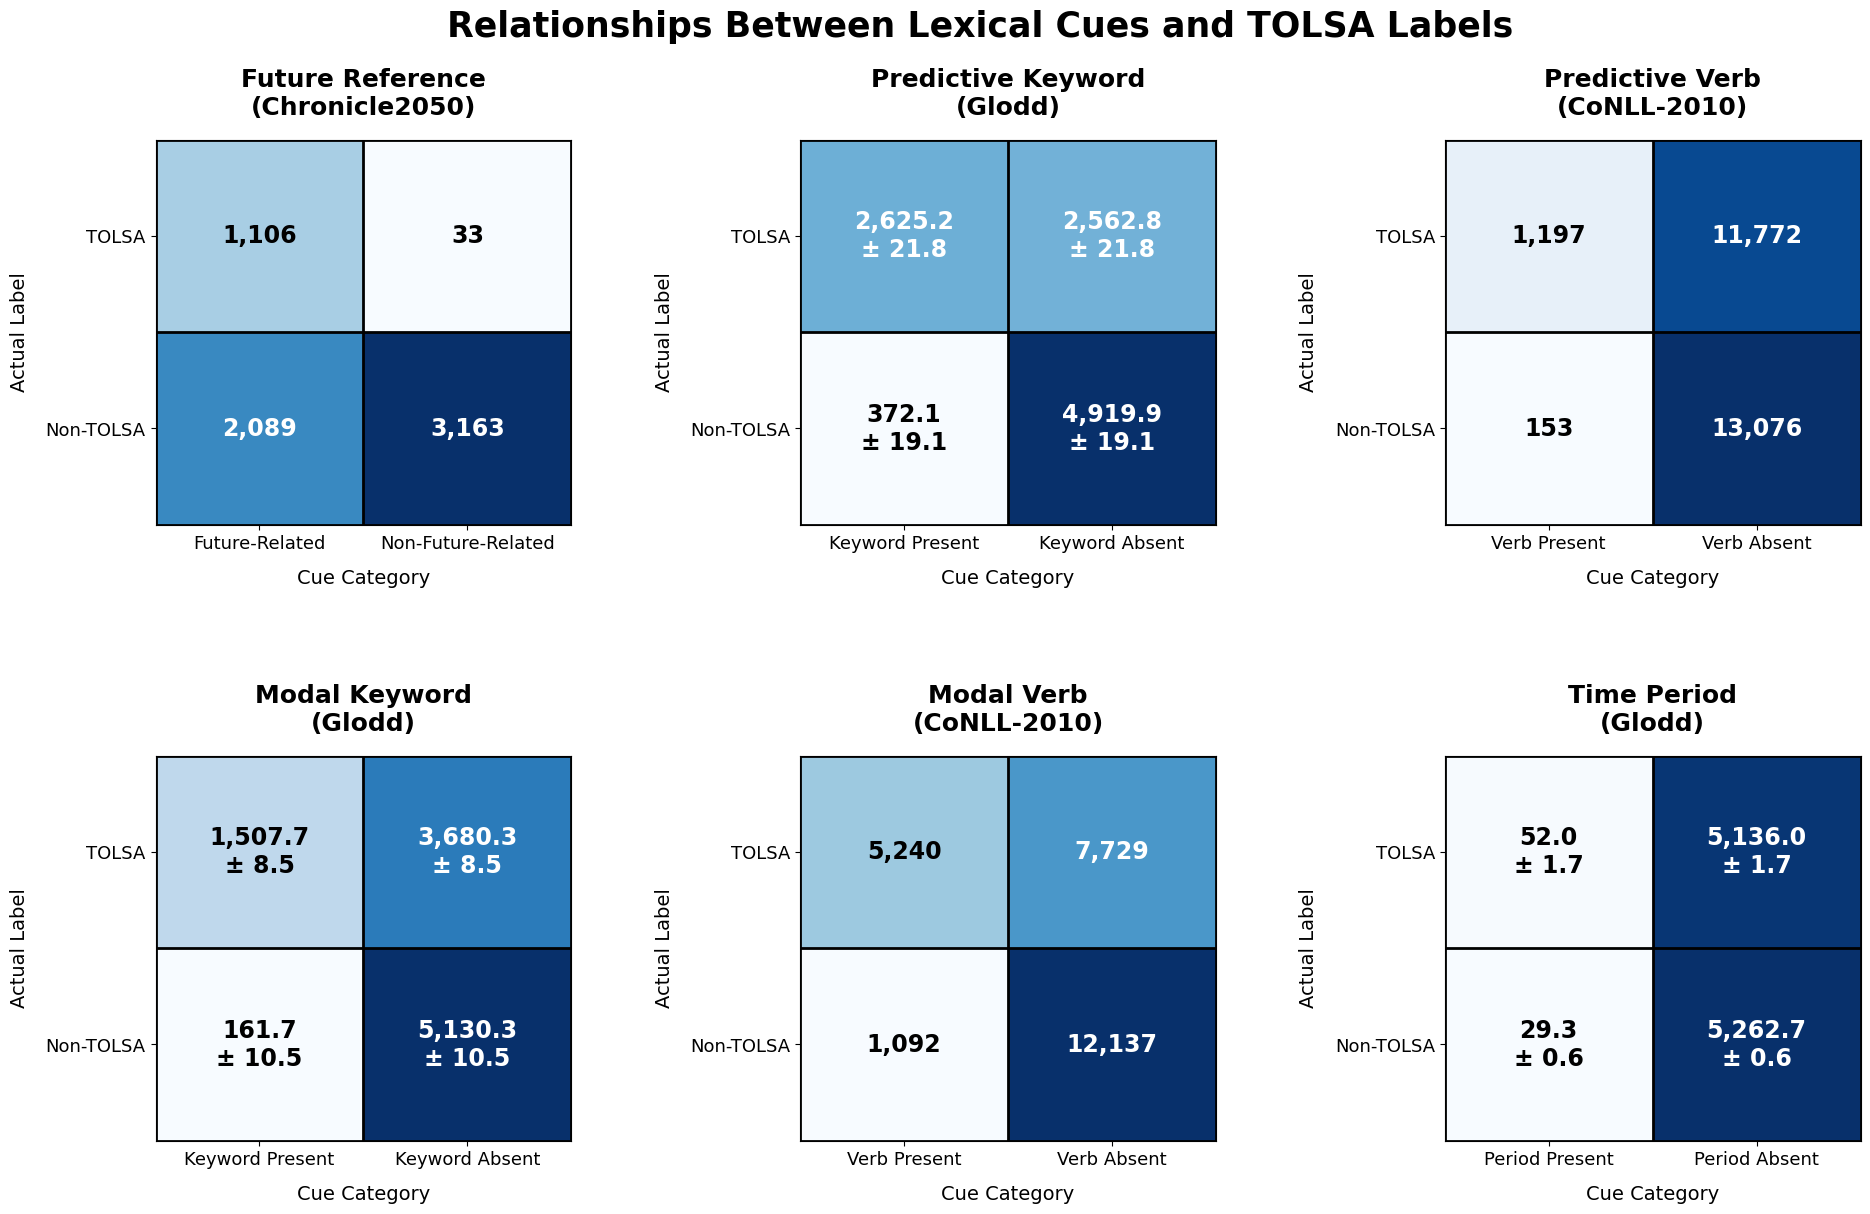

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Rows: Actual labels [TOLSA, Non-TOLSA]
# Columns: Cue [Present, Absent]

matrices = [
    {
        "title": "Future Reference\n(Chronicle2050)",
        "columns": ["Future-Related", "Non-Future-Related"],
        "values": np.array([
            [1106, 33],
            [2089, 3163],
        ]),
        "stds": np.array([
            [0.0, 0.0],
            [0.0, 0.0],
        ]),
    },
    {
        "title": "Predictive Keyword\n(Glodd)",
        "columns": ["Keyword Present", "Keyword Absent"],
        "values": np.array([
            [2625.2, 2562.8],
            [372.1, 4919.9],
        ]),
        "stds": np.array([
            [21.8, 21.8],
            [19.1, 19.1],
        ]),
    },
    {
        "title": "Predictive Verb\n(CoNLL-2010)",
        "columns": ["Verb Present", "Verb Absent"],
        "values": np.array([
            [1197.0, 11772.0],
            [153.0, 13076.0],
        ]),
        "stds": np.zeros((2, 2)),
    },
    {
        "title": "Modal Keyword\n(Glodd)",
        "columns": ["Keyword Present", "Keyword Absent"],
        "values": np.array([
            [1507.7, 3680.3],
            [161.7, 5130.3],
        ]),
        "stds": np.array([
            [8.5, 8.5],
            [10.5, 10.5],
        ]),
    },
    {
        "title": "Modal Verb\n(CoNLL-2010)",
        "columns": ["Verb Present", "Verb Absent"],
        "values": np.array([
            [5240.0, 7729.0],
            [1092.0, 12137.0],
        ]),
        "stds": np.zeros((2, 2)),
    },
    {
        "title": "Time Period\n(Glodd)",
        "columns": ["Period Present", "Period Absent"],
        "values": np.array([
            [52.0, 5136.0],
            [29.3, 5262.7],
        ]),
        "stds": np.array([
            [1.7, 1.7],
            [0.6, 0.6],
        ]),
    },
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(22, 13),
)

axes = axes.flatten()

for ax, matrix_info in zip(axes, matrices):
    values = matrix_info["values"]
    stds = matrix_info["stds"]

    image = ax.imshow(
        values,
        cmap="Blues",
        aspect="auto",
    )

    ax.set_title(
        matrix_info["title"],
        fontsize=18,
        fontweight="bold",
        pad=18,
    )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        matrix_info["columns"],
        fontsize=13,
    )

    ax.set_yticks([0, 1])
    ax.set_yticklabels(
        ["TOLSA", "Non-TOLSA"],
        fontsize=13,
    )

    ax.set_xlabel(
        "Cue Category",
        fontsize=14,
        labelpad=12,
    )

    ax.set_ylabel(
        "Actual Label",
        fontsize=14,
        labelpad=12,
    )

    threshold = values.max() / 2

    for row in range(2):
        for column in range(2):
            value = values[row, column]
            std = stds[row, column]

            if std > 0:
                text = f"{value:,.1f}\n± {std:.1f}"
            else:
                text = f"{value:,.0f}"

            ax.text(
                column,
                row,
                text,
                ha="center",
                va="center",
                fontsize=17,
                fontweight="bold",
                color=(
                    "white"
                    if value > threshold
                    else "black"
                ),
            )

    ax.set_xticks(
        np.arange(-0.5, 2, 1),
        minor=True,
    )
    ax.set_yticks(
        np.arange(-0.5, 2, 1),
        minor=True,
    )

    ax.grid(
        which="minor",
        color="black",
        linestyle="-",
        linewidth=2,
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

fig.suptitle(
    "Relationships Between Lexical Cues and TOLSA Labels",
    fontsize=25,
    fontweight="bold",
    y=0.98,
)

plt.subplots_adjust(
    wspace=0.55,
    hspace=0.60,
)

plt.show()

# output_path = "tolsa_cue_confusion_matrices.png"

# plt.savefig(
#     output_path,
#     dpi=300,
#     bbox_inches="tight",
#     facecolor="white",
# )



# print(f"Saved image: {output_path}")

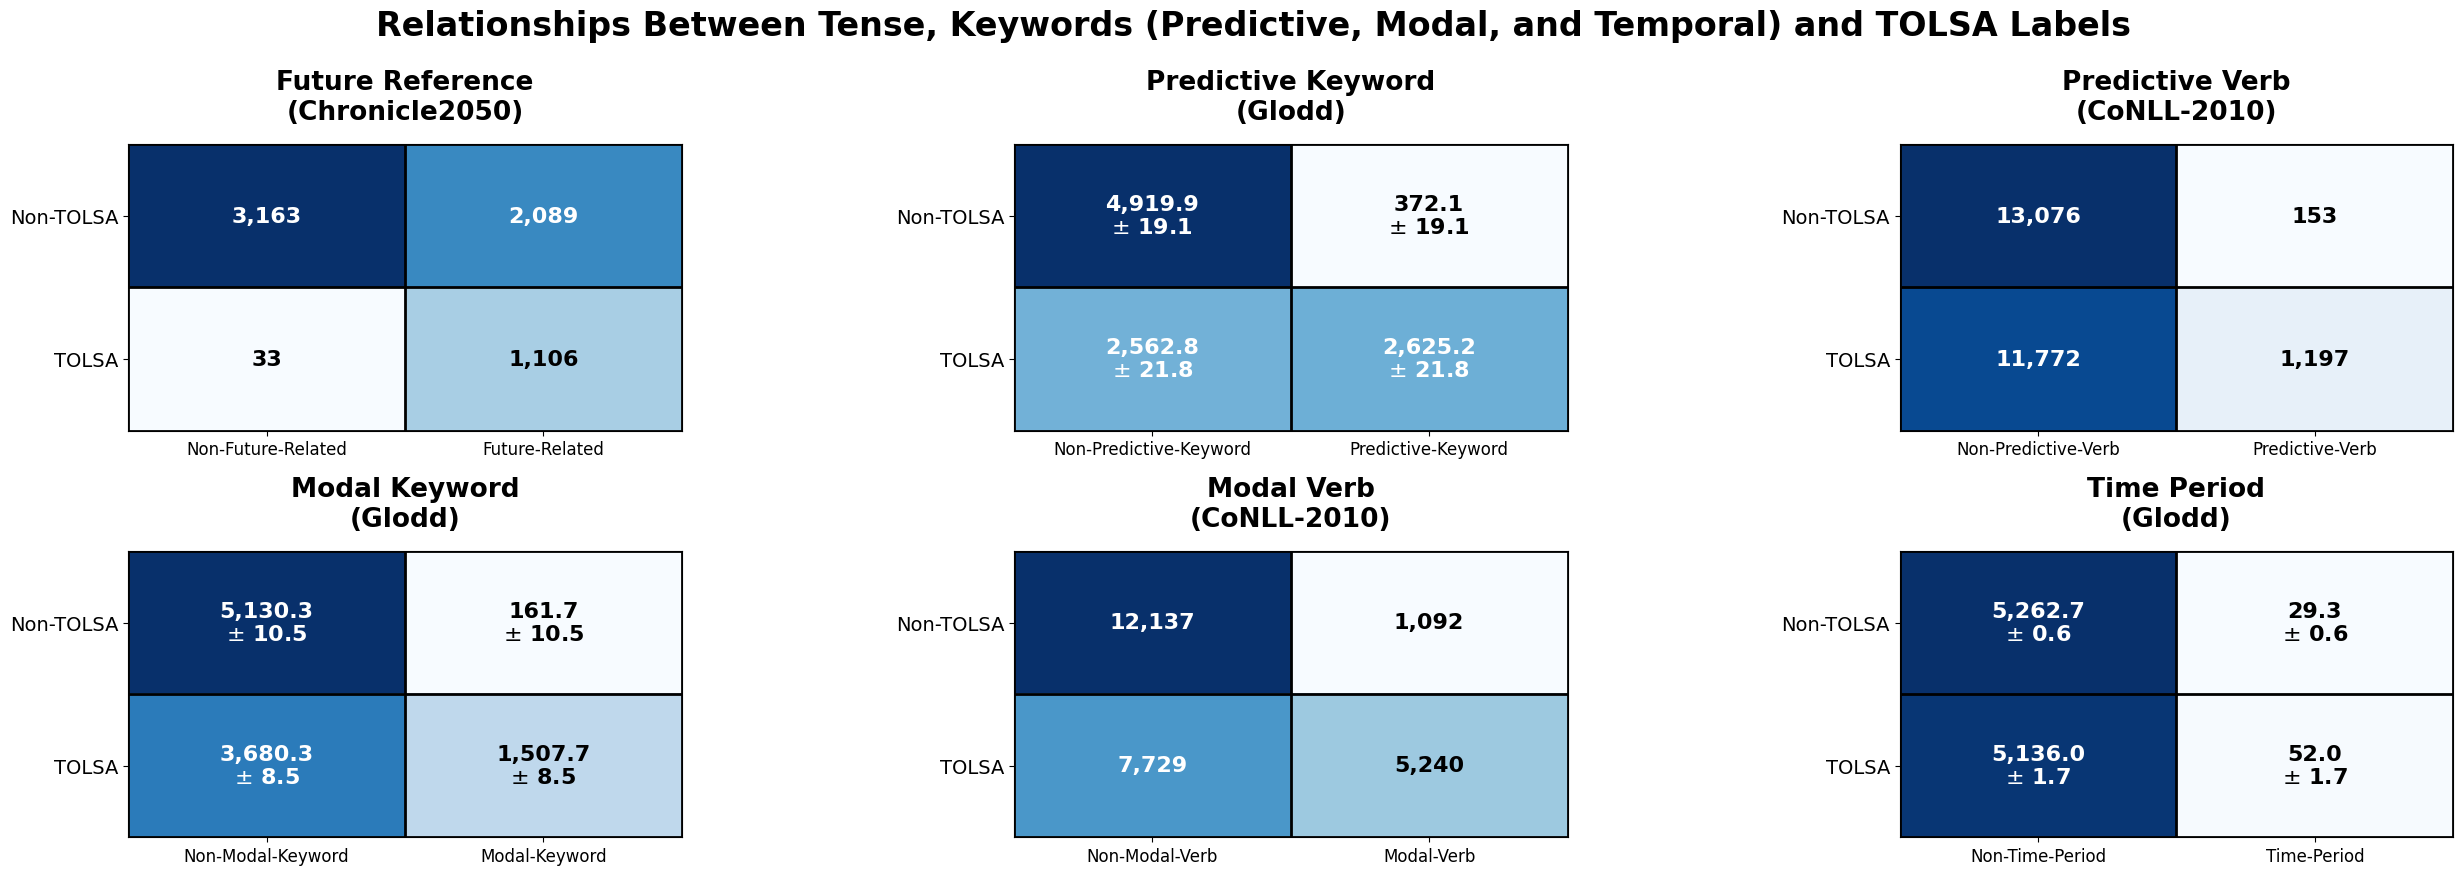

In [13]:
import matplotlib.pyplot as plt
import numpy as np

matrices = [
    {
        "title": "Future Reference\n(Chronicle2050)",
        "columns": [
            "Non-Future-Related",
            "Future-Related",
        ],
        "values": np.array([
            [3163, 2089],
            [33, 1106],
        ]),
        "stds": np.zeros((2, 2)),
    },
    {
        "title": "Predictive Keyword\n(Glodd)",
        "columns": [
            "Non-Predictive-Keyword",
            "Predictive-Keyword",
        ],
        "values": np.array([
            [4919.9, 372.1],
            [2562.8, 2625.2],
        ]),
        "stds": np.array([
            [19.1, 19.1],
            [21.8, 21.8],
        ]),
    },
    {
        "title": "Predictive Verb\n(CoNLL-2010)",
        "columns": [
            "Non-Predictive-Verb",
            "Predictive-Verb",
        ],
        "values": np.array([
            [13076.0, 153.0],
            [11772.0, 1197.0],
        ]),
        "stds": np.zeros((2, 2)),
    },
    {
        "title": "Modal Keyword\n(Glodd)",
        "columns": [
            "Non-Modal-Keyword",
            "Modal-Keyword",
        ],
        "values": np.array([
            [5130.3, 161.7],
            [3680.3, 1507.7],
        ]),
        "stds": np.array([
            [10.5, 10.5],
            [8.5, 8.5],
        ]),
    },
    {
        "title": "Modal Verb\n(CoNLL-2010)",
        "columns": [
            "Non-Modal-Verb",
            "Modal-Verb",
        ],
        "values": np.array([
            [12137.0, 1092.0],
            [7729.0, 5240.0],
        ]),
        "stds": np.zeros((2, 2)),
    },
    {
        "title": "Time Period\n(Glodd)",
        "columns": [
            "Non-Time-Period",
            "Time-Period",
        ],
        "values": np.array([
            [5262.7, 29.3],
            [5136.0, 52.0],
        ]),
        "stds": np.array([
            [0.6, 0.6],
            [1.7, 1.7],
        ]),
    },
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(30, 9),
)

axes = axes.flatten()

for ax, matrix_info in zip(axes, matrices):
    values = matrix_info["values"]
    stds = matrix_info["stds"]

    ax.imshow(
        values,
        cmap="Blues",
        aspect="auto",
    )

    ax.set_title(
        matrix_info["title"],
        fontsize=19,
        fontweight="bold",
        pad=18,
    )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        matrix_info["columns"],
        fontsize=12,
    )

    ax.set_yticks([0, 1])
    ax.set_yticklabels(
        [
            "Non-TOLSA",
            "TOLSA",
        ],
        fontsize=14,
    )

    # ax.set_xlabel(
    #     "Cue Label",
    #     fontsize=14,
    #     labelpad=14,
    # )

    # ax.set_ylabel(
    #     "Actual Label",
    #     fontsize=14,
    #     labelpad=14,
    # )

    threshold = values.max() / 2

    for row in range(2):
        for column in range(2):
            value = values[row, column]
            std = stds[row, column]

            if std > 0:
                annotation = (
                    f"{value:,.1f}\n"
                    f"$\\pm$ {std:.1f}"
                )
            else:
                annotation = f"{value:,.0f}"

            ax.text(
                column,
                row,
                annotation,
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color=(
                    "white"
                    if value > threshold
                    else "black"
                ),
            )

    ax.set_xticks(
        np.arange(-0.5, 2, 1),
        minor=True,
    )

    ax.set_yticks(
        np.arange(-0.5, 2, 1),
        minor=True,
    )

    ax.grid(
        which="minor",
        color="black",
        linestyle="-",
        linewidth=2,
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

fig.suptitle(
    "Relationships Between Tense, Keywords (Predictive, Modal, and Temporal) "
    "and TOLSA Labels",
    fontsize=24,
    fontweight="bold",
    y=1.03,
)

plt.subplots_adjust(
    wspace=0.60,
    hspace=0.42,
)

plt.show()